In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

C:\Users\Jalaja Madhusudhanan\AppData\Local\Temp\ipykernel_1436\4041120328.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# load files saved from stageposition_data_analysis (matlab code)
hit_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\hit_speed.csv",delimiter=',',header=None)
miss_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\miss_speed.csv",delimiter=',',header=None)

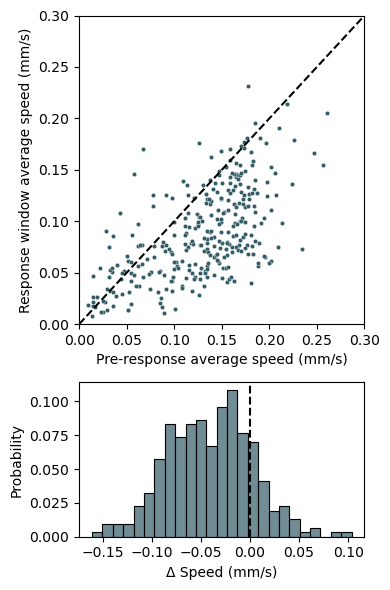

In [28]:

# Compute means in specified ranges
hit_start_value = hit_speed.iloc[:, 600:630].mean(axis=1)
miss_start_value = miss_speed.iloc[:, 600:630].mean(axis=1)
hit_preres_value = hit_speed.iloc[:, 640:685].mean(axis=1)
miss_preres_value = miss_speed.iloc[:, 640:685].mean(axis=1)

# Combine hit and miss data
x_values = np.concatenate([hit_start_value, miss_start_value])
y_values = np.concatenate([hit_preres_value, miss_preres_value])
diff_values = np.concatenate([(hit_preres_value - hit_start_value), (miss_preres_value - miss_start_value)])

# Create figure and axes with vertical layout
fig, axes = plt.subplots(2, 1, figsize=(4, 6), gridspec_kw={'height_ratios': [2, 1]})

# Scatter plot (left)
ax1 = axes[0]
sns.scatterplot(x=x_values, y=y_values, color='#335c67', s=10, alpha=1, ax=ax1)
ax1.plot([0, 0.3], [0, 0.3], '--', color='black')  # y = x line
ax1.set_xlabel("Pre-response average speed (mm/s)")
ax1.set_ylabel("Response window average speed (mm/s)")
ax1.set_xlim(0, 0.3)
ax1.set_ylim(0, 0.3)

# Histogram (right)
ax2 = axes[1]
sns.histplot(diff_values, bins=25, color='#335c67', alpha=0.7, kde=False, stat="probability", ax=ax2)
ax2.axvline(0, linestyle='dashed', color='black')  # Vertical line at 0
ax2.set_xlabel("Δ Speed (mm/s)")
ax2.set_ylabel("Probability")

# Adjust layout
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
plt.savefig('slowing_speed_scatter_histo.svg', format='svg', dpi=300)
plt.show()


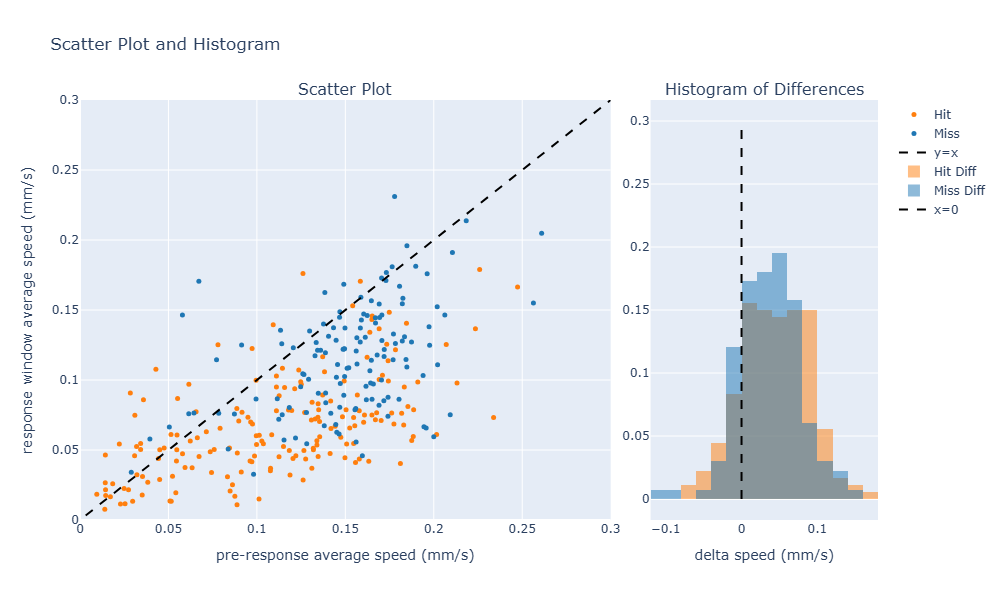

In [4]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
# 
# Load the data
hit_speed = pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\hit_speed.csv", header=None)
miss_speed = pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\miss_speed.csv", header=None)

# Calculate mean values across the specified intervals
hit_start_value = hit_speed.iloc[:, 600:630].mean(axis=1)
miss_start_value = miss_speed.iloc[:, 600:630].mean(axis=1)
hit_preres_value = hit_speed.iloc[:, 640:685].mean(axis=1)
miss_preres_value = miss_speed.iloc[:, 640:685].mean(axis=1)



# Scatter plot for Hit and Miss points
scatter_hit = go.Scatter(
    x=hit_start_value, y=hit_preres_value,
    mode='markers', marker=dict(color='#ff7f0e', size=5),
    name='Hit'
)
scatter_miss = go.Scatter(
    x=miss_start_value, y=miss_preres_value,
    mode='markers', marker=dict(color='#1f77b4', size=5),
    name='Miss'
)

# Create figure with subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Scatter Plot", "Histogram of Differences"),
    column_widths=[0.7, 0.3],
    horizontal_spacing=0.05
)

# Add scatter plot traces to the first subplot (left)
fig.add_trace(scatter_hit, row=1, col=1)
fig.add_trace(scatter_miss, row=1, col=1)

# Add a black dashed line y=x in the scatter plot
diagonal_line = go.Scatter(
    x=[-0.3, 0.3], y=[-0.3, 0.3],
    mode='lines', line=dict(color='black', dash='dash'),
    name='y=x'
)
fig.add_trace(diagonal_line, row=1, col=1)

# Calculate differences along y = -x for hit and miss
hit_diff = (hit_start_value - hit_preres_value) 
miss_diff = (miss_start_value - miss_preres_value)

# Create histograms for hit_diff and miss_diff
fig.add_trace(go.Histogram(
    x=hit_diff, opacity=0.5, marker=dict(color='#ff7f0e'),
    name='Hit Diff', xbins=dict(size=0.02), histnorm='probability'
), row=1, col=2)

fig.add_trace(go.Histogram(
    x=miss_diff, opacity=0.5, marker=dict(color='#1f77b4'),
    name='Miss Diff', xbins=dict(size=0.02), histnorm='probability'
), row=1, col=2)

# Add a vertical black dashed line at x=0 in the histogram
hist_vertical_line = go.Scatter(
    x=[0, 0], y=[0, 0.3],  # x=0, y from 0 to 1 (height of the histogram)
    mode='lines', line=dict(color='black', dash='dash'),
    name='x=0'
)
fig.add_trace(hist_vertical_line, row=1, col=2)

# Update axis settings
fig.update_xaxes(title_text="pre-response average speed (mm/s)", range=[0, 0.3], row=1, col=1)
fig.update_yaxes(title_text="response window average speed (mm/s)", range=[0, 0.3], row=1, col=1)

# Update histogram axis settings
fig.update_xaxes(title_text="delta speed (mm/s)", row=1, col=2)
# fig.update_yaxes(title_text="Frequency", row=1, col=2)

# Update layout
fig.update_layout(
    title="Scatter Plot and Histogram",
    showlegend=True,
    height=600,
    width=1000,
    barmode='overlay'
)

# Show the figure
fig.show()
pio.write_image(fig, 'slowing_speed_scatter_histo.png', width=1000, height=600)

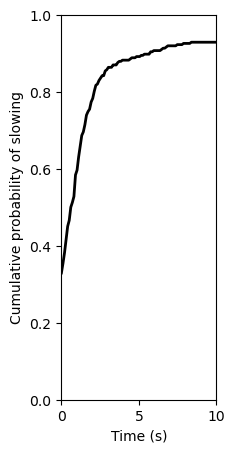

In [110]:
# Define smoothing function
def smooth_and_diff(data, sigma=5):
    smoothed = gaussian_filter1d(data, sigma=sigma, axis=1)  # Smooth along time axis
    # smoothed = data # Smooth along time axis
    derivative = np.diff(smoothed, axis=1)  # Compute first derivative
    return derivative

# Apply smoothing and compute derivatives
hit_derivative = smooth_and_diff(hit_speed.values)
miss_derivative = smooth_and_diff(miss_speed.values)

# Define time window
start, end = 600, 700
time_range = np.arange(start, end)

# Function to detect the first frame where slowing occurs
def detect_slowing_first_frame(derivative, start, end, threshold=5):
    num_trials, num_timepoints = derivative.shape
    slowing_matrix = np.zeros((num_trials, num_timepoints))  # Initialize as all 0s

    for trial_idx, trial in enumerate(derivative):
        neg_frames = np.zeros(num_timepoints)
        neg_frames[start:end] = trial[start:end] < 0  # Mark negative derivative frames

        # Find first frame where slowing persists for more than `threshold` frames
        for t in range(start, end - threshold):
            if np.sum(neg_frames[t:t + threshold]) >= threshold:
                slowing_matrix[trial_idx, t] = 1  # Mark only the first frame
                break  # Stop after finding the first slowing event

    return slowing_matrix[:, start:end]  # Return only the relevant window

# Create binary time series (1 at first slowing frame, 0 elsewhere)
hit_slowing_timeseries = detect_slowing_first_frame(hit_derivative, start, end)
miss_slowing_timeseries = detect_slowing_first_frame(miss_derivative, start, end)

# Sum slowing events across trials (single time series)
total_slowing_timeseries = np.sum(hit_slowing_timeseries, axis=0) + np.sum(miss_slowing_timeseries, axis=0)

# Normalize time range to 0-10
time_range_normalized = np.linspace(0, 10, len(time_range))

# Compute total number of trials
total_trials = hit_slowing_timeseries.shape[0] + miss_slowing_timeseries.shape[0]

# Compute cumulative probability (fraction of trials with slowing)
total_cumulative_probability = np.cumsum(total_slowing_timeseries) / total_trials

# Plot cumulative probability over time
plt.figure(figsize=(2, 5))
plt.plot(time_range_normalized, total_cumulative_probability, color="black", linewidth=2)
plt.xlabel("Time (s)")  # Now the x-axis is in seconds
plt.ylabel("Cumulative probability of slowing")
# plt.title("Cumulative Probability of Slowing Events Over Time (600-685)")
plt.ylim(0, 1)  # Probability should be between 0 and 1
plt.xlim(0, 10)  # Ensure x-axis goes from 0 to 10
# plt.grid(True)
plt.rcParams['svg.fonttype'] = 'none'
# Save as SVG
plt.savefig("cumulative_slowing.svg", format="svg")

# Show plot
plt.show()

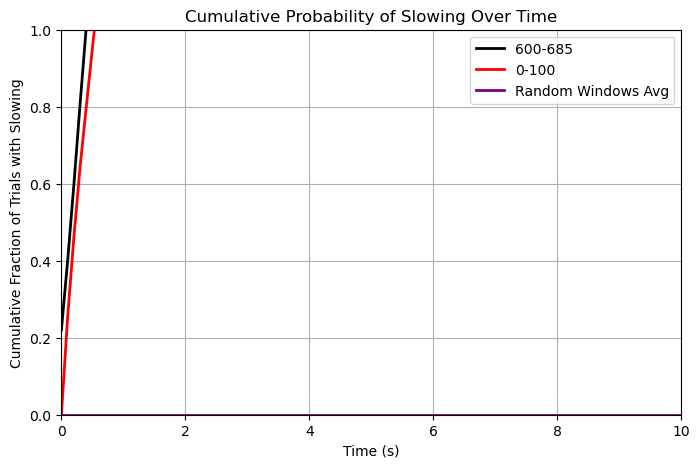

In [101]:

# Convert to numpy arrays
hit_speed = hit_speed.to_numpy()
miss_speed = miss_speed.to_numpy()

# Combine hit & miss data
all_speed = np.vstack([hit_speed, miss_speed])

# Define smoothing function
def smooth_data(data, sigma=2):
    return scipy.ndimage.gaussian_filter1d(data, sigma=sigma, axis=1)

# Apply smoothing
all_smooth = smooth_data(all_speed)

# Compute derivative along time axis
all_derivative = np.diff(all_smooth, axis=1, prepend=np.nan)

# Function to detect slowing events
def detect_slowing(derivative, start_frame, end_frame,threshold=5):
    slowing_matrix = np.zeros_like(derivative)
    for trial in range(derivative.shape[0]):  # Loop over trials
        for i in range(start_frame, end_frame - threshold):  # Ensure at least 20 frames available
            if np.all(derivative[trial, i:i+threshold] < 0):  # Check if 20 consecutive frames are negative
                slowing_matrix[trial, i] = 1  # Mark the first frame of slowing
    return slowing_matrix

# Compute slowing matrices for combined data
slowing_1 = detect_slowing(all_derivative, 600, 700)  # Window: 600-685
slowing_2 = detect_slowing(all_derivative, 0, 100)    # Window: 0-100

# Generate 100 random windows (100 frames length, starting anywhere from 0 to 500)
num_random_windows = 100
random_window_length = 100
random_start_points = np.random.randint(0, 500, num_random_windows)

# Normalize time range (0-10 sec)
   
time_range = np.linspace(0, 10, 100)  # Expanded window (0-100)

# Function to compute cumulative probability
def compute_cumulative_probability(slowing_matrix, start_frame, end_frame):
    total_trials = slowing_matrix.shape[0]
    slowing_window = slowing_matrix[:, start_frame:end_frame]
    probability_timeseries = np.sum(slowing_window, axis=0) / total_trials  # Fraction of trials slowing
    return np.cumsum(probability_timeseries)  # Cumulative probability

# Compute cumulative probabilities for fixed windows
cumulative_prob_1 = compute_cumulative_probability(slowing_1, 600, 700)
cumulative_prob_2 = compute_cumulative_probability(slowing_2, 0, 100)

# Compute cumulative probability for 100 random windows and average them
cumulative_probs_random = np.zeros((num_random_windows, random_window_length))

for i, start in enumerate(random_start_points):
    cumulative_probs_random[i, :] = compute_cumulative_probability(slowing_1, start, start + random_window_length)

# Compute mean of the 100 random windows
avg_cumulative_prob_random = np.mean(cumulative_probs_random, axis=0)

# Plot results
plt.figure(figsize=(8, 5))

plt.plot(time_range, cumulative_prob_1, label="600-685", color="black", linewidth=2)
plt.plot(time_range, cumulative_prob_2, label="0-100", color="red", linewidth=2)
plt.plot(time_range, avg_cumulative_prob_random, label="Random Windows Avg", color="purple", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Cumulative Fraction of Trials with Slowing")
plt.title("Cumulative Probability of Slowing Over Time")
plt.ylim(0, 1)  # Ensure probability stays between 0 and 1
plt.xlim(0, 10)  # Standardized x-axis
plt.legend()
plt.grid(True)

# # Save as SVG for Adobe Illustrator
# plt.savefig("cumulative_slowing_combined.svg", format="svg")

# Show plot
plt.show()
